# HỌC MÁY – BÀI THỰC HÀNH
## Phần: Mô Hình Trộn Gaussian (Gaussian Mixture Model)

Notebook này bao gồm:
1. **Phần 2.1** – Thuật toán EM xây dựng từ Numpy (Ví dụ 1 + Bài tập 1 & 2)
2. **Phần 2.2** – Sử dụng thư viện scikit-learn (Ví dụ 2)
3. **Phần 2.3** – Ví dụ mở rộng với dữ liệu Sales Transactions

---
## 2.1 Thuật toán EM – Xây dựng từ Numpy
### Khai báo thư viện

In [27]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import multivariate_normal
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Thư viện đã được nạp thành công!')

Thư viện đã được nạp thành công!


### Hàm tạo dữ liệu nhân tạo 2D

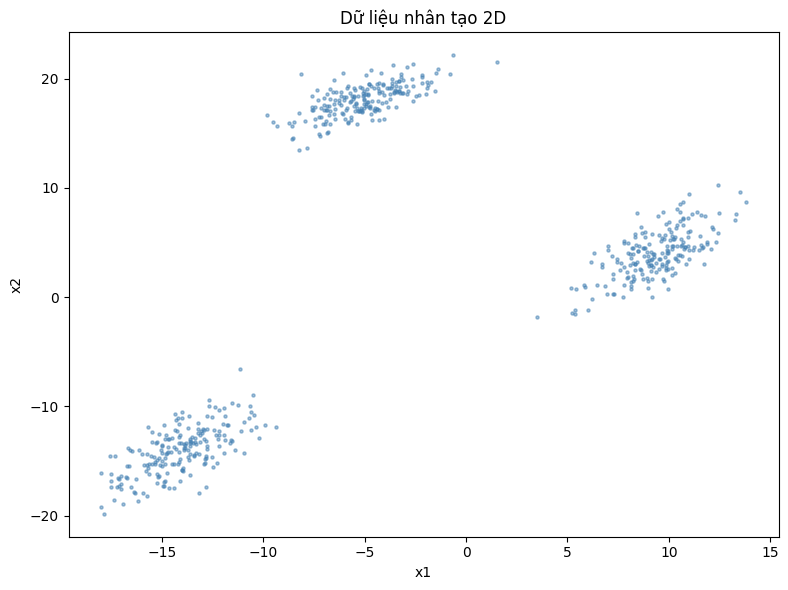

Kích thước dữ liệu: (600, 2)


In [28]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=[-20, 20], seed=42):
    """
    Sinh dữ liệu ngẫu nhiên từ hỗn hợp các phân phối Gaussian.
    Input:
      - k: Số cụm Gaussian
      - dim: Số chiều
      - points_per_cluster: Số điểm mỗi cụm
      - lim: Khoảng giá trị của mean
    Output:
      - X: Mảng dữ liệu (points_per_cluster*k, dim)
    """
    np.random.seed(seed)
    x = []
    mean = random.rand(k, dim) * (lim[1] - lim[0]) + lim[0]
    for i in range(k):
        cov = random.rand(dim, dim + 10)
        cov = np.matmul(cov, cov.T)
        _x = np.random.multivariate_normal(mean[i], cov, points_per_cluster)
        x += list(_x)
    x = np.array(x)
    if dim == 2:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(x[:, 0], x[:, 1], s=5, alpha=0.5, c='steelblue')
        ax.set_title('Dữ liệu nhân tạo 2D')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.autoscale(enable=True)
        plt.tight_layout()
        plt.show()
    return x

# Sinh dữ liệu
X_2d = gen_data(k=3, dim=2, points_per_cluster=200)
print(f'Kích thước dữ liệu: {X_2d.shape}')

### Class GMM – Thuật toán EM

In [29]:
class GMM_EM:
    def __init__(self, k, dim, init_mu=None, init_sigma=None, init_pi=None, colors=None):
        self.k = k
        self.dim = dim

        if init_mu is None:
            init_mu = random.rand(k, dim) * 20 - 10
        self.mu = init_mu.copy()

        if init_sigma is None:
            init_sigma = np.zeros((k, dim, dim))
            for i in range(k):
                init_sigma[i] = np.eye(dim) * 2.0  # Khởi tạo với phương sai lớn hơn
        self.sigma = init_sigma.copy()

        if init_pi is None:
            init_pi = np.ones(self.k) / self.k
        self.pi = init_pi.copy()

        if colors is None:
            colors = random.rand(k, 3)
        self.colors = colors

    def fit(self, data, max_iters=100, tol=1e-4):
        self.data = data
        self.num_points = data.shape[0]
        self.z = np.zeros((self.num_points, self.k))
        self.log_likelihoods = []

        for iteration in range(max_iters):
            try:
                self.e_step()
                self.m_step()
                ll = self.log_likelihood()
                self.log_likelihoods.append(ll)
                if iteration > 0 and abs(self.log_likelihoods[-1] - self.log_likelihoods[-2]) < tol:
                    print(f'Hội tụ sau {iteration + 1} vòng lặp.')
                    break
            except np.linalg.LinAlgError:
                print(f'Vòng lặp {iteration}: Ma trận suy biến, thêm regularization...')
                # Tăng regularization và thử lại
                for i in range(self.k):
                    self.sigma[i] += 1e-4 * np.eye(self.dim)

    def e_step(self):
        for i in range(self.k):
            try:
                self.z[:, i] = self.pi[i] * multivariate_normal.pdf(
                    self.data, mean=self.mu[i], cov=self.sigma[i], allow_singular=True
                )
            except:
                # Nếu vẫn lỗi, dùng pseudo-inverse
                from scipy.linalg import pinv
                cov_inv = pinv(self.sigma[i])
                det = max(np.linalg.det(self.sigma[i]), 1e-10)
                const = 1.0 / (np.sqrt((2*np.pi)**self.dim * det))
                diff = self.data - self.mu[i]
                exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
                self.z[:, i] = self.pi[i] * const * np.exp(exponent)
        self.z /= self.z.sum(axis=1, keepdims=True)

    def m_step(self, reg_covar=1e-6):
        sum_z = self.z.sum(axis=0)
        self.pi = sum_z / self.num_points
        self.mu = np.matmul(self.z.T, self.data)
        self.mu /= sum_z[:, None]
        
        for i in range(self.k):
            diff = self.data - self.mu[i]
            sigma_i = (diff.T * self.z[:, i]) @ diff / sum_z[i]
            # Regularization để tránh singular
            sigma_i += reg_covar * np.eye(self.dim)
            # Đảm bảo đối xứng
            self.sigma[i] = (sigma_i + sigma_i.T) / 2

    def log_likelihood(self):
        ll = np.zeros(self.num_points)
        for i in range(self.k):
            try:
                ll += self.pi[i] * multivariate_normal.pdf(
                    self.data, mean=self.mu[i], cov=self.sigma[i], allow_singular=True
                )
            except:
                from scipy.linalg import pinv
                cov_inv = pinv(self.sigma[i])
                det = max(np.linalg.det(self.sigma[i]), 1e-10)
                const = 1.0 / (np.sqrt((2*np.pi)**self.dim * det))
                diff = self.data - self.mu[i]
                exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
                ll += self.pi[i] * const * np.exp(exponent)
        return np.sum(np.log(ll + 1e-300))

    def predict(self):
        return np.argmax(self.z, axis=1)

    def plot_log_likelihood(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.log_likelihoods, marker='o', markersize=3)
        plt.title('Log-Likelihood qua các vòng lặp EM')
        plt.xlabel('Vòng lặp')
        plt.ylabel('Log-Likelihood')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_clusters_2d(self, title='Kết quả phân cụm GMM (EM)'):
        if self.dim != 2:
            print('Chỉ hỗ trợ vẽ dữ liệu 2 chiều!')
            return
        labels = self.predict()
        palette = sns.color_palette('hls', self.k)
        fig, ax = plt.subplots(figsize=(8, 6))
        for i in range(self.k):
            idx = labels == i
            ax.scatter(self.data[idx, 0], self.data[idx, 1],
                       s=10, alpha=0.6, color=palette[i], label=f'Cụm {i}')
            ax.scatter(*self.mu[i], s=200, marker='*',
                       color=palette[i], edgecolors='black', zorder=5)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### Ví dụ 1 – Chạy GMM_EM trên dữ liệu nhân tạo 2D

Hội tụ sau 6 vòng lặp.

--- Kết quả tham số ước lượng ---
Trọng số pi: [0.3333 0.3333 0.3333]
Mean mu:
 [[ -5.0963  18.0627]
 [  9.3523   3.9917]
 [-14.1018 -14.0381]]


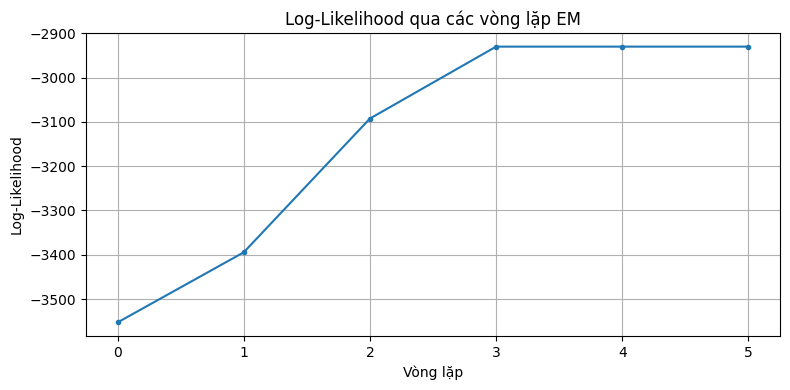

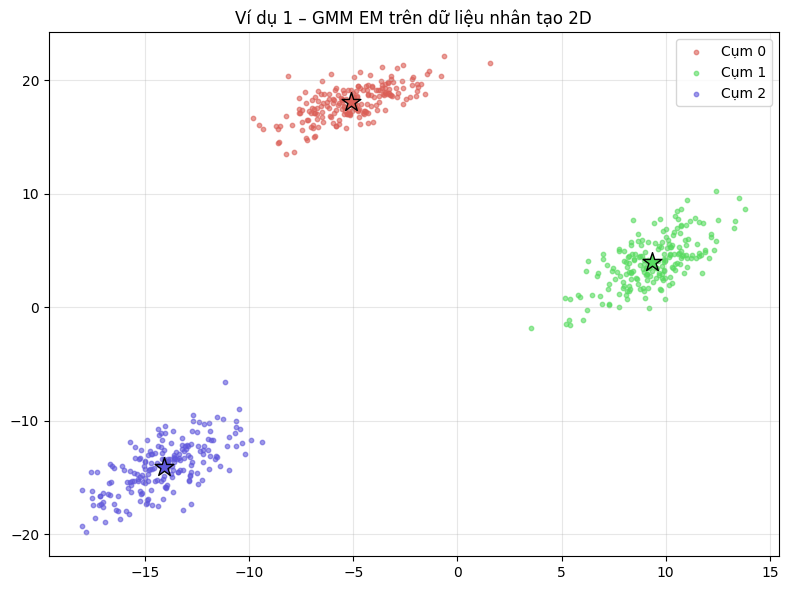

In [30]:
np.random.seed(0)
gmm_2d = GMM_EM(k=3, dim=2)
gmm_2d.fit(X_2d, max_iters=200, tol=1e-6)

print('\n--- Kết quả tham số ước lượng ---')
print('Trọng số pi:', np.round(gmm_2d.pi, 4))
print('Mean mu:\n', np.round(gmm_2d.mu, 4))

gmm_2d.plot_log_likelihood()
gmm_2d.plot_clusters_2d(title='Ví dụ 1 – GMM EM trên dữ liệu nhân tạo 2D')

---
## Bài Tập Tự Thực Hành 1
### Áp dụng GMM_EM cho dữ liệu Iris (bỏ cột nhãn loài)

**Yêu cầu:** Phân cụm tập dữ liệu Iris bằng thuật toán EM tự cài đặt, sau đó đối sánh kết quả với nhãn thực.

In [31]:
# ---- Tải và khám phá dữ liệu Iris ----
iris = load_iris()
X_iris = iris.data          # (150, 4) – 4 đặc trưng
y_iris = iris.target         # Nhãn thực: 0, 1, 2
target_names = iris.target_names

print('Kích thước dữ liệu Iris:', X_iris.shape)
print('Các loài hoa:', target_names)
print('Phân bố nhãn:', dict(zip(*np.unique(y_iris, return_counts=True))))

df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris['species'] = [target_names[i] for i in y_iris]
df_iris.head()

Kích thước dữ liệu Iris: (150, 4)
Các loài hoa: ['setosa' 'versicolor' 'virginica']
Phân bố nhãn: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Hội tụ sau 2 vòng lặp.
Nhãn cụm dự đoán (50 mẫu đầu): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


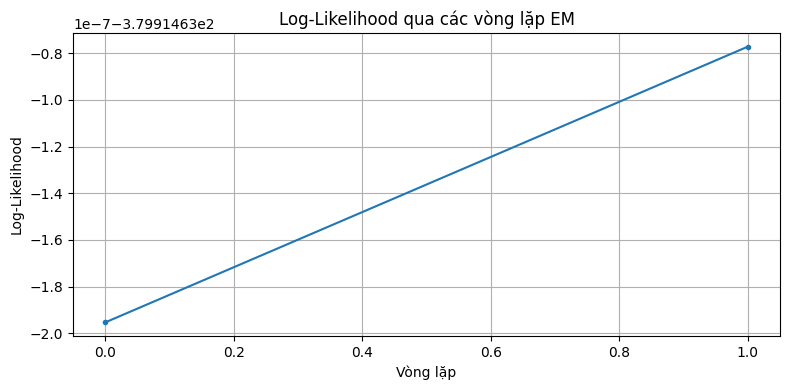

In [32]:
# ---- Phân cụm GMM với k=3 ----
np.random.seed(42)
gmm_iris = GMM_EM(k=3, dim=4)
gmm_iris.fit(X_iris, max_iters=300, tol=1e-6)

labels_iris = gmm_iris.predict()
print('Nhãn cụm dự đoán (50 mẫu đầu):', labels_iris[:50])

gmm_iris.plot_log_likelihood()

Adjusted Rand Index (ARI): 0.0000  (1.0 = hoàn hảo, 0 = ngẫu nhiên)

Ma trận đối sánh (hàng = nhãn thực, cột = cụm dự đoán):
                  Cụm 0  Cụm 1  Cụm 2
Thực: setosa         50      0      0
Thực: versicolor     50      0      0
Thực: virginica      50      0      0


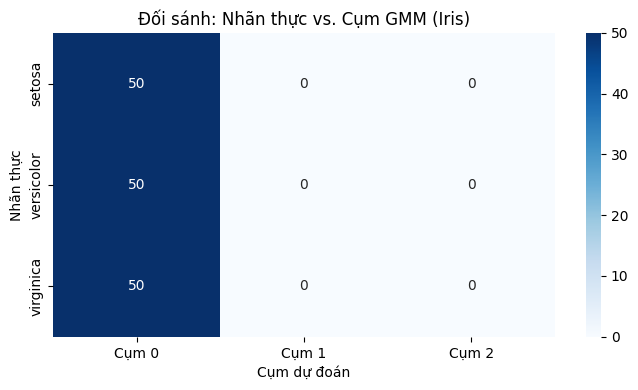

In [33]:
# ---- Đối sánh kết quả phân cụm với nhãn thực ----
# Dùng Adjusted Rand Index để đánh giá (không phụ thuộc vào thứ tự nhãn)
ari = adjusted_rand_score(y_iris, labels_iris)
print(f'Adjusted Rand Index (ARI): {ari:.4f}  (1.0 = hoàn hảo, 0 = ngẫu nhiên)')

# Hiển thị ma trận đối sánh cụm vs. nhãn thực
conf = confusion_matrix(y_iris, labels_iris)
print('\nMa trận đối sánh (hàng = nhãn thực, cột = cụm dự đoán):')
df_conf = pd.DataFrame(conf,
                        index=[f'Thực: {n}' for n in target_names],
                        columns=[f'Cụm {i}' for i in range(3)])
print(df_conf)

plt.figure(figsize=(7, 4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cụm {i}' for i in range(3)],
            yticklabels=target_names)
plt.title('Đối sánh: Nhãn thực vs. Cụm GMM (Iris)')
plt.ylabel('Nhãn thực')
plt.xlabel('Cụm dự đoán')
plt.tight_layout()
plt.show()

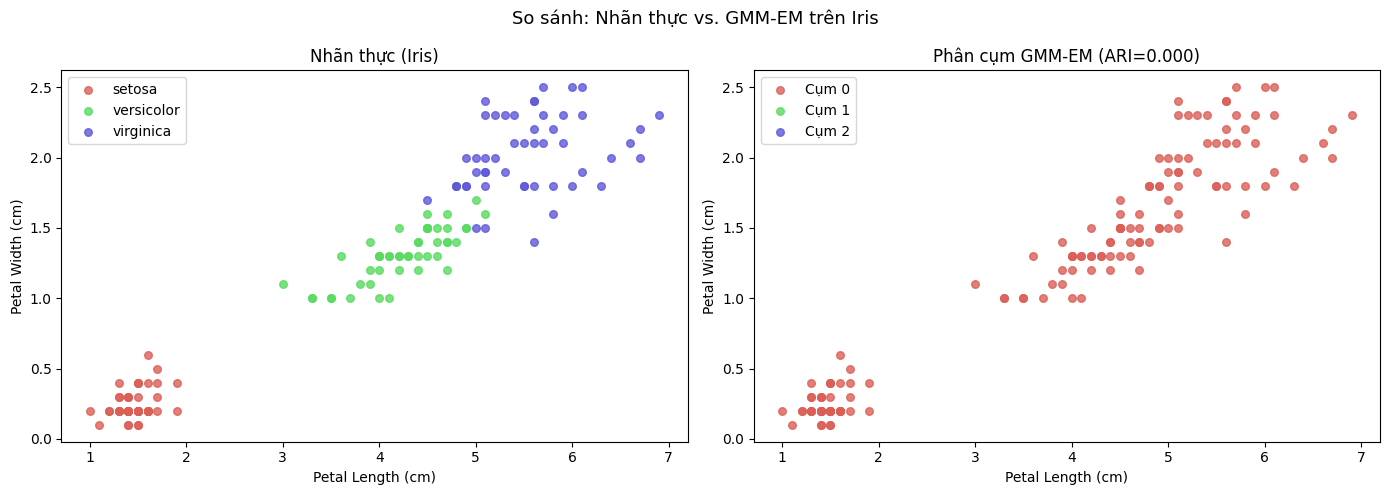


Nhận xét: GMM-EM phân tách tốt Setosa (cụm riêng biệt), nhưng có thể nhầm lẫn giữa Versicolor và Virginica vì chúng chồng lấp.


In [34]:
# ---- Trực quan hóa bằng 2 đặc trưng đại diện ----
# Dùng petal length và petal width (cột 2, 3) vì phân tách tốt nhất
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('hls', 3)

# Nhãn thực
for i in range(3):
    idx = y_iris == i
    axes[0].scatter(X_iris[idx, 2], X_iris[idx, 3],
                    color=palette[i], label=target_names[i], s=30, alpha=0.8)
axes[0].set_title('Nhãn thực (Iris)')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend()

# Nhãn GMM
for i in range(3):
    idx = labels_iris == i
    axes[1].scatter(X_iris[idx, 2], X_iris[idx, 3],
                    color=palette[i], label=f'Cụm {i}', s=30, alpha=0.8)
axes[1].set_title(f'Phân cụm GMM-EM (ARI={ari:.3f})')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend()

plt.suptitle('So sánh: Nhãn thực vs. GMM-EM trên Iris', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNhận xét: GMM-EM phân tách tốt Setosa (cụm riêng biệt), '
      'nhưng có thể nhầm lẫn giữa Versicolor và Virginica vì chúng chồng lấp.')

---
## Bài Tập Tự Thực Hành 2
### So sánh GMM vs. K-Means trên dữ liệu nhân tạo 2D

**Yêu cầu:** Dùng K-Means để phân cụm dữ liệu tự tạo ở Ví dụ 1. So sánh với kết quả của GMM.

In [35]:
# ---- K-Means trên dữ liệu nhân tạo 2D ----
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_2d)

print('Kết quả K-Means:')
print('Số điểm mỗi cụm:', dict(zip(*np.unique(labels_km, return_counts=True))))
print('Tâm cụm:\n', np.round(kmeans.cluster_centers_, 3))

Kết quả K-Means:
Số điểm mỗi cụm: {np.int32(0): np.int64(200), np.int32(1): np.int64(200), np.int32(2): np.int64(200)}
Tâm cụm:
 [[  9.352   3.992]
 [-14.102 -14.038]
 [ -5.096  18.063]]


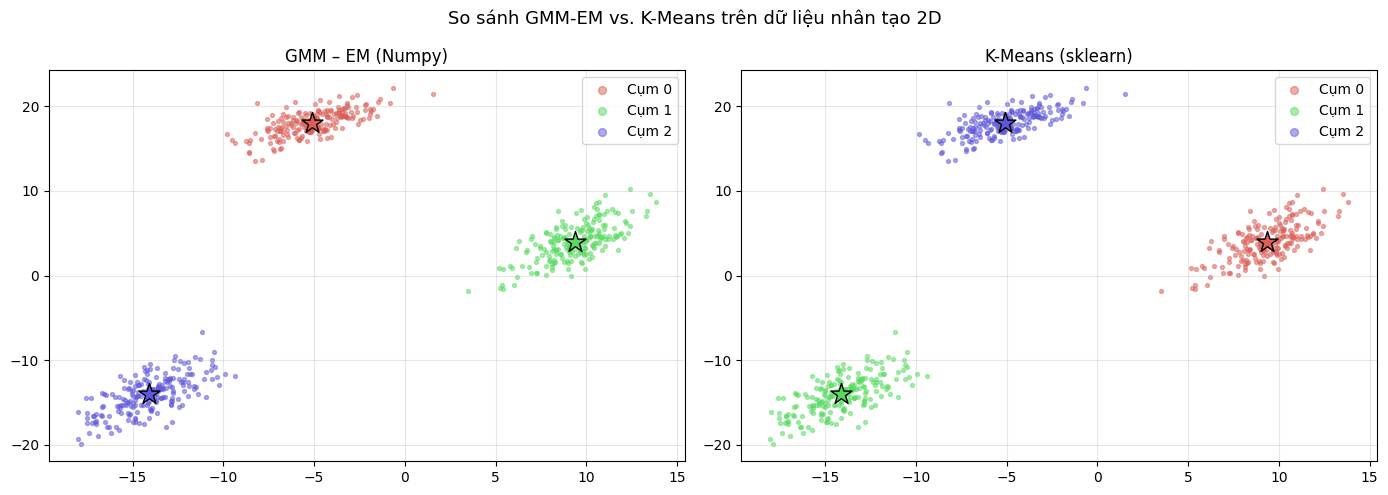

In [36]:
# ---- Lấy lại nhãn GMM trên dữ liệu 2D ----
labels_gmm_2d = gmm_2d.predict()

# ---- Vẽ so sánh ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('hls', 3)

titles = ['GMM – EM (Numpy)', 'K-Means (sklearn)']
all_labels = [labels_gmm_2d, labels_km]
centers_list = [gmm_2d.mu, kmeans.cluster_centers_]

for ax, title, lbs, centers in zip(axes, titles, all_labels, centers_list):
    for i in range(3):
        idx = lbs == i
        ax.scatter(X_2d[idx, 0], X_2d[idx, 1],
                   color=palette[i], s=8, alpha=0.5, label=f'Cụm {i}')
        ax.scatter(centers[i, 0], centers[i, 1],
                   s=250, marker='*', color=palette[i], edgecolors='black', zorder=5)
    ax.set_title(title, fontsize=12)
    ax.legend(markerscale=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('So sánh GMM-EM vs. K-Means trên dữ liệu nhân tạo 2D', fontsize=13)
plt.tight_layout()
plt.show()

In [37]:
# ---- Phân tích sự khác biệt ----
print('=' * 60)
print('PHÂN TÍCH SO SÁNH GMM-EM vs. K-MEANS')
print('=' * 60)
print("""
1. K-Means:
   - Giả định các cụm có dạng HÌnh CẦU (covariance = I * sigma^2)
   - Phân ranh giới cụm theo khoảng cách Euclidean
   - Kết quả có thể sai khi dữ liệu có hình dạng elip, nghiêng
   - Nhanh hơn, ít tham số hơn

2. GMM-EM:
   - Mô hình xác suất linh hoạt hơn
   - Ma trận covariance FULL → xử lý tốt cụm elip, xoay nghiêng
   - Cung cấp soft assignment (xác suất thuộc từng cụm)
   - Cần nhiều tham số và tính toán hơn
   - Nhạy với giá trị khởi tạo (có thể dùng K-Means để khởi tạo)

=> Với dữ liệu nhân tạo có covariance KHÔNG song song trục tọa độ,
   GMM-EM thường cho kết quả tốt hơn K-Means.
""")

PHÂN TÍCH SO SÁNH GMM-EM vs. K-MEANS

1. K-Means:
   - Giả định các cụm có dạng HÌnh CẦU (covariance = I * sigma^2)
   - Phân ranh giới cụm theo khoảng cách Euclidean
   - Kết quả có thể sai khi dữ liệu có hình dạng elip, nghiêng
   - Nhanh hơn, ít tham số hơn

2. GMM-EM:
   - Mô hình xác suất linh hoạt hơn
   - Ma trận covariance FULL → xử lý tốt cụm elip, xoay nghiêng
   - Cung cấp soft assignment (xác suất thuộc từng cụm)
   - Cần nhiều tham số và tính toán hơn
   - Nhạy với giá trị khởi tạo (có thể dùng K-Means để khởi tạo)

=> Với dữ liệu nhân tạo có covariance KHÔNG song song trục tọa độ,
   GMM-EM thường cho kết quả tốt hơn K-Means.



---
## 2.2 Sử dụng thư viện scikit-learn
### Ví dụ 2 – Phân cụm dữ liệu Shopping (thu nhập & chỉ số mua sắm)

**Dữ liệu:** `shopping-data.csv` – 2 trường: Annual Income & Spending Score

In [38]:
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture

# ---- Bước (i): Đọc dữ liệu ----
# Tạo dữ liệu mô phỏng shopping-data nếu chưa có file
try:
    data = pd.read_csv('shopping-data.csv', header=0, index_col=0)
    print('Đọc file thành công!')
except FileNotFoundError:
    print('Không tìm thấy file. Tạo dữ liệu mô phỏng...')
    np.random.seed(0)
    n = 200
    # Tạo 5 nhóm khách hàng có thu nhập và chi tiêu khác nhau
    clusters_params = [
        ([20, 20], [[30, 5], [5, 30]]),
        ([20, 80], [[30, -5], [-5, 30]]),
        ([60, 50], [[50, 0], [0, 50]]),
        ([100, 20], [[30, 5], [5, 30]]),
        ([100, 80], [[30, -5], [-5, 30]]),
    ]
    rows = []
    for (mu, cov) in clusters_params:
        pts = np.random.multivariate_normal(mu, cov, 40)
        rows.append(pts)
    pts = np.vstack(rows)
    pts = np.clip(pts, 0, 120)
    data = pd.DataFrame({
        'CustomerID': range(1, len(pts) + 1),
        'Genre': np.random.choice(['Male', 'Female'], len(pts)),
        'Annual Income (k$)': pts[:, 0].astype(int),
        'Spending Score (1-100)': pts[:, 1].astype(int)
    })
    data = data.set_index('CustomerID')

print('Kích thước dữ liệu:', data.shape)
print(data.head())

Đọc file thành công!
Kích thước dữ liệu: (200, 4)
             Genre  Age  Annual Income (k$)  Spending Score (1-100)
CustomerID                                                         
1             Male   19                  15                      39
2             Male   21                  15                      81
3           Female   20                  16                       6
4           Female   23                  16                      77
5           Female   31                  17                      40


In [39]:
# ---- Trích xuất 2 trường và chuẩn hóa ----
X_shop = data.iloc[:, 2:4].values
print('Dữ liệu gốc – Annual Income & Spending Score:')
print(f'  Min: {X_shop.min(axis=0)}, Max: {X_shop.max(axis=0)}')

scaler = MinMaxScaler()
X_std = scaler.fit_transform(X_shop)
print(f'\nSau chuẩn hóa – kích thước: {X_std.shape}')
print(f'  Min: {X_std.min(axis=0).round(3)}, Max: {X_std.max(axis=0).round(3)}')

Dữ liệu gốc – Annual Income & Spending Score:
  Min: [15  1], Max: [137  99]

Sau chuẩn hóa – kích thước: (200, 2)
  Min: [0. 0.], Max: [1. 1.]


In [40]:
# ---- Bước (v): Chọn số cụm K tối ưu qua BIC Score ----
lowest_bic = np.inf
bic = []
n_components_range = range(1, 7)
cv_types = ['full', 'tied']

for cv_type in cv_types:
    for n_components in n_components_range:
        gmm_tmp = GaussianMixture(n_components=n_components,
                                  covariance_type=cv_type,
                                  random_state=0)
        gmm_tmp.fit(X_std)
        bic.append(gmm_tmp.bic(X_std))
        if bic[-1] < lowest_bic:
            lowest_bic = bic[-1]
            best_gmm = gmm_tmp

bic = np.array(bic)
print(f'Mô hình tốt nhất: n_components={best_gmm.n_components}, covariance_type={best_gmm.covariance_type}')
print(f'BIC tốt nhất: {lowest_bic:.2f}')

Mô hình tốt nhất: n_components=5, covariance_type=full
BIC tốt nhất: -91.14


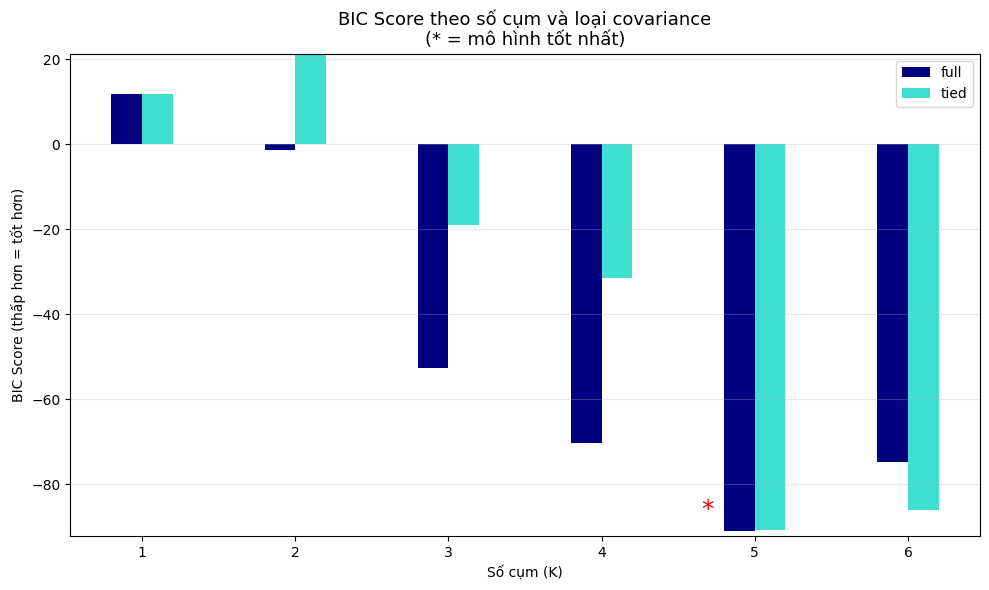

In [41]:
# ---- Vẽ biểu đồ BIC ----
color_iter = itertools.cycle(['navy', 'turquoise'])
bars_list = []

plt.figure(figsize=(10, 6))
for i, (cv_type, color) in enumerate(zip(cv_types, color_iter)):
    xpos = np.array(n_components_range) + 0.2 * (i - 0.5)
    b = plt.bar(xpos,
                bic[i * len(n_components_range): (i + 1) * len(n_components_range)],
                width=0.2, color=color, label=cv_type)
    bars_list.append(b)

plt.xticks(n_components_range)
plt.ylim([bic.min() * 1.01 - 0.01 * bic.max(), bic.max() * 1.02])
plt.title('BIC Score theo số cụm và loại covariance\n(* = mô hình tốt nhất)', fontsize=13)
plt.xlabel('Số cụm (K)')
plt.ylabel('BIC Score (thấp hơn = tốt hơn)')

xpos_star = np.mod(bic.argmin(), len(n_components_range)) + 0.65 + \
            0.2 * np.floor(bic.argmin() / len(n_components_range))
plt.text(xpos_star, bic.min() * 0.97 + 0.03 * bic.max(), '*', fontsize=18, color='red')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# ---- Bước (ii) & (iii): Khởi tạo và huấn luyện mô hình tối ưu ----
K_opt = best_gmm.n_components
gm = GaussianMixture(n_components=K_opt,
                     covariance_type=best_gmm.covariance_type,
                     random_state=0)
gm.fit(X_std)

print(f'Mô hình GMM với K={K_opt} cụm:')
print('Trọng số pi:', np.round(gm.weights_, 4))
print('Means:\n', np.round(gm.means_, 4))

Mô hình GMM với K=5 cụm:
Trọng số pi: [0.4133 0.1655 0.1967 0.1209 0.1035]
Means:
 [[0.3337 0.4939]
 [0.605  0.1543]
 [0.5839 0.8267]
 [0.0986 0.216 ]
 [0.0829 0.8074]]


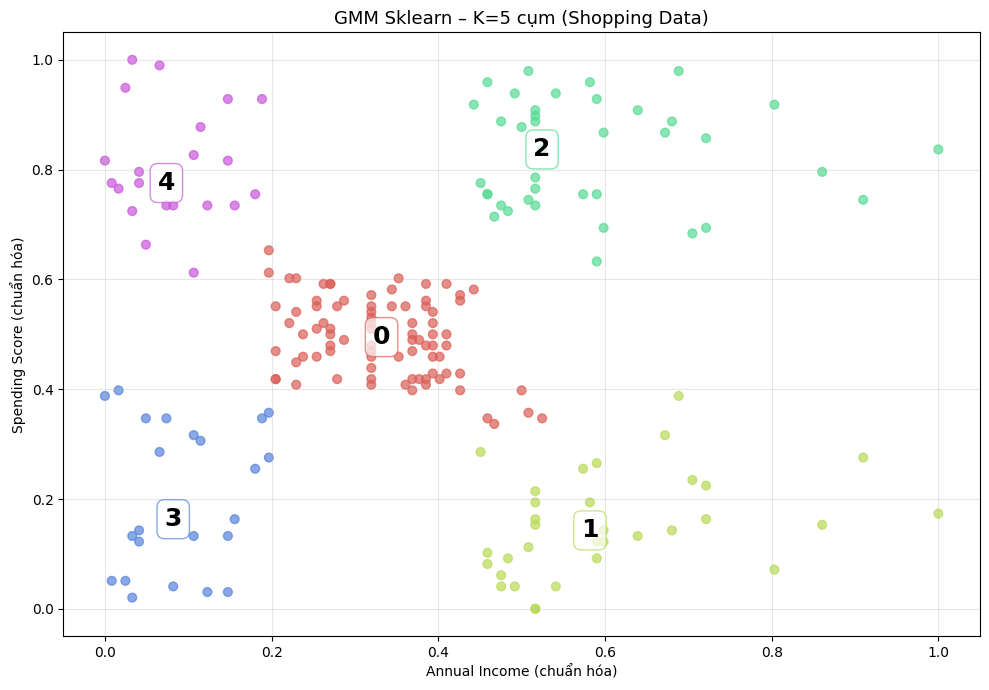

In [43]:
# ---- Bước (iv): Hiển thị kết quả phân cụm ----
def plot_gmm_scatter(X, labels, title='GMM Clustering'):
    num_classes = len(np.unique(labels))
    palette = np.array(sns.color_palette('hls', num_classes))
    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(X[:, 0], X[:, 1], s=40, alpha=0.7,
                    c=palette[labels.astype(int)])
    for i in range(num_classes):
        xtext, ytext = np.median(X[labels == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=18, fontweight='bold',
                      ha='center', va='center')
        txt.set_bbox(dict(boxstyle='round', fc='white', ec=palette[i], alpha=0.7))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Annual Income (chuẩn hóa)')
    ax.set_ylabel('Spending Score (chuẩn hóa)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

labels_shop = gm.predict(X_std)
plot_gmm_scatter(X_std, labels_shop,
                 title=f'GMM Sklearn – K={K_opt} cụm (Shopping Data)')

---
## 2.3 Ví dụ Mở Rộng
### Phân cụm sản phẩm theo giao dịch hàng tuần (Sales Transactions Dataset)

**Dữ liệu:** `Sales_Transactions_Dataset_Weekly.csv`  
- 819 mã sản phẩm, giao dịch 52 tuần (week 0 – week 51)  
- Số cụm K tối ưu dự kiến trong khoảng **5 – 15**

In [44]:
from sklearn.decomposition import PCA

# ---- Đọc dữ liệu ----
try:
    df_sales = pd.read_csv('Sales_Transactions_Dataset_Weekly.csv')
    print('Đọc file thành công!')
except FileNotFoundError:
    print('Không tìm thấy file Sales_Transactions_Dataset_Weekly.csv.')
    print('Tạo dữ liệu mô phỏng 819 sản phẩm x 52 tuần...')
    np.random.seed(0)
    n_products = 819
    n_weeks = 52
    # Giả lập 8 nhóm sản phẩm với xu hướng giao dịch khác nhau
    n_groups = 8
    group_size = n_products // n_groups
    rows = []
    for g in range(n_groups):
        base = np.sin(np.linspace(0, g * np.pi / 2, n_weeks)) * (g + 1) * 100 + 200
        noise = np.random.randn(group_size, n_weeks) * 30
        rows.append(base + noise)
    data_weeks = np.vstack(rows)
    cols = [f'W{i}' for i in range(n_weeks)]
    df_sales = pd.DataFrame(data_weeks, columns=cols)
    df_sales.insert(0, 'Product_Code', [f'P{i:04d}' for i in range(len(df_sales))])

print('Kích thước dữ liệu:', df_sales.shape)
df_sales.head(3)

Đọc file thành công!
Kích thước dữ liệu: (811, 107)


,Product_Code,W0,W1,W2,W3,W4,W5,W6,W7,W8,...,Normalized 42,Normalized 43,Normalized 44,Normalized 45,Normalized 46,Normalized 47,Normalized 48,Normalized 49,Normalized 50,Normalized 51
0,P1,11,12,10,8,13,12,14,21,6,...,0.06,0.22,0.28,0.39,0.50,0.00,0.22,0.17,0.11,0.39
1,P2,7,6,3,2,7,1,6,3,3,...,0.20,0.40,0.50,0.10,0.10,0.40,0.50,0.10,0.60,0.00
2,P3,7,11,8,9,10,8,7,13,12,...,0.27,1.00,0.18,0.18,0.36,0.45,1.00,0.45,0.45,0.36


In [45]:
# ---- Tiền xử lý: trích xuất 52 tuần giao dịch ----
# Xác định các cột tuần (bắt đầu bằng 'W' hoặc 'week' hoặc cột số)
week_cols = [c for c in df_sales.columns if str(c).startswith('W') and str(c)[1:].isdigit()]
if not week_cols:
    # Thử nhận diện cột số
    week_cols = [c for c in df_sales.select_dtypes(include=[np.number]).columns]

print(f'Số cột tuần tìm được: {len(week_cols)}')
print('Tên cột:', week_cols[:5], '...')

X_sales = df_sales[week_cols].values.astype(float)

# Chuẩn hóa theo hàng (từng sản phẩm)
from sklearn.preprocessing import StandardScaler
scaler_s = StandardScaler()
X_sales_scaled = scaler_s.fit_transform(X_sales)

print(f'\nMa trận dữ liệu sau chuẩn hóa: {X_sales_scaled.shape}')

Số cột tuần tìm được: 52
Tên cột: ['W0', 'W1', 'W2', 'W3', 'W4'] ...

Ma trận dữ liệu sau chuẩn hóa: (811, 52)


In [46]:
# ---- Xác định số cụm K tối ưu (BIC, K = 5..15) ----
print('Đang tính BIC cho K = 5 đến 15... (có thể mất vài phút)')

bic_scores = []
aic_scores = []
K_range = range(5, 16)

for k_val in K_range:
    gmm_k = GaussianMixture(n_components=k_val,
                             covariance_type='diag',  # dùng diag cho dữ liệu chiều cao
                             max_iter=200,
                             n_init=3,
                             random_state=42)
    gmm_k.fit(X_sales_scaled)
    bic_scores.append(gmm_k.bic(X_sales_scaled))
    aic_scores.append(gmm_k.aic(X_sales_scaled))
    print(f'  K={k_val}: BIC={bic_scores[-1]:.1f}, AIC={aic_scores[-1]:.1f}')

K_best = K_range[np.argmin(bic_scores)]
print(f'\n=> K tối ưu theo BIC: K = {K_best}')

Đang tính BIC cho K = 5 đến 15... (có thể mất vài phút)
  K=5: BIC=-28186.6, AIC=-30648.5
  K=6: BIC=-27872.1, AIC=-30827.3
  K=7: BIC=-28303.5, AIC=-31752.1
  K=8: BIC=-27800.7, AIC=-31742.6
  K=9: BIC=-27346.9, AIC=-31782.1
  K=10: BIC=-32918.0, AIC=-37846.5
  K=11: BIC=-26592.4, AIC=-32014.2
  K=12: BIC=-31795.7, AIC=-37710.8
  K=13: BIC=-32044.1, AIC=-38452.5
  K=14: BIC=-30928.6, AIC=-37830.4
  K=15: BIC=-30385.8, AIC=-37780.8

=> K tối ưu theo BIC: K = 10


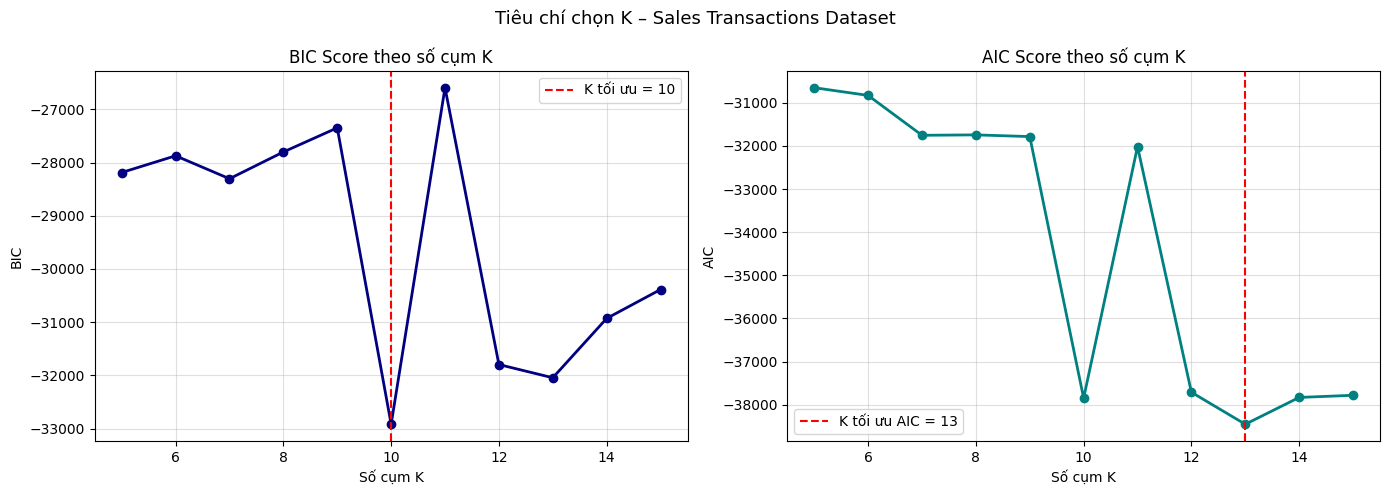

In [47]:
# ---- Vẽ BIC và AIC ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), bic_scores, 'o-', color='navy', linewidth=2)
axes[0].axvline(K_best, color='red', linestyle='--', label=f'K tối ưu = {K_best}')
axes[0].set_title('BIC Score theo số cụm K', fontsize=12)
axes[0].set_xlabel('Số cụm K')
axes[0].set_ylabel('BIC')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(list(K_range), aic_scores, 'o-', color='teal', linewidth=2)
axes[1].axvline(K_range[np.argmin(aic_scores)], color='red', linestyle='--',
                label=f'K tối ưu AIC = {K_range[np.argmin(aic_scores)]}')
axes[1].set_title('AIC Score theo số cụm K', fontsize=12)
axes[1].set_xlabel('Số cụm K')
axes[1].set_ylabel('AIC')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Tiêu chí chọn K – Sales Transactions Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# ---- Huấn luyện mô hình GMM với K tối ưu ----
gmm_sales = GaussianMixture(n_components=K_best,
                             covariance_type='diag',
                             max_iter=300,
                             n_init=5,
                             random_state=42)
gmm_sales.fit(X_sales_scaled)

labels_sales = gmm_sales.predict(X_sales_scaled)
print(f'Phân cụm xong với K={K_best}.')
print('Số sản phẩm mỗi cụm:')
unique, counts = np.unique(labels_sales, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cụm {c}: {n} sản phẩm')

Phân cụm xong với K=10.
Số sản phẩm mỗi cụm:
  Cụm 0: 59 sản phẩm
  Cụm 1: 185 sản phẩm
  Cụm 2: 187 sản phẩm
  Cụm 3: 39 sản phẩm
  Cụm 4: 111 sản phẩm
  Cụm 5: 23 sản phẩm
  Cụm 6: 38 sản phẩm
  Cụm 7: 113 sản phẩm
  Cụm 8: 50 sản phẩm
  Cụm 9: 6 sản phẩm


Phương sai giải thích: PC1=91.90%, PC2=1.06%, Tổng=92.96%


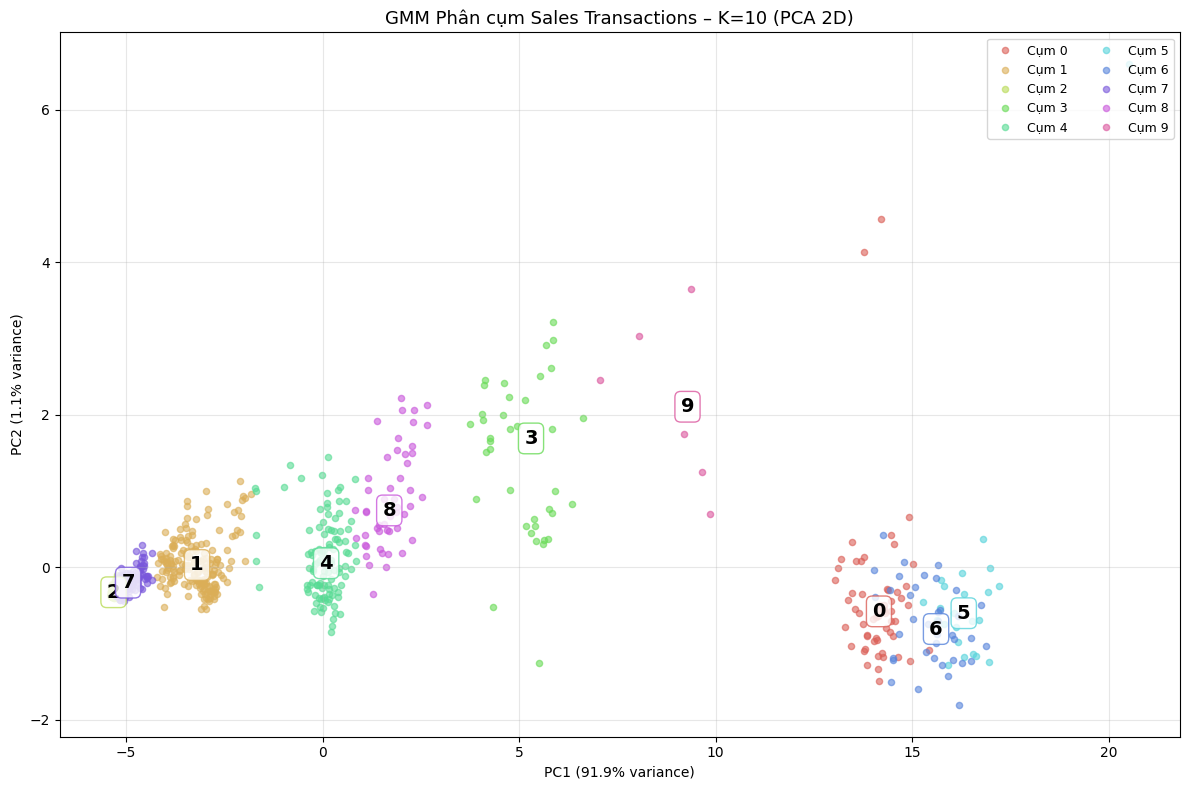

In [49]:
# ---- Giảm chiều bằng PCA để trực quan hóa ----
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sales_scaled)
explained = pca.explained_variance_ratio_
print(f'Phương sai giải thích: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}, Tổng={sum(explained):.2%}')

palette = sns.color_palette('hls', K_best)
fig, ax = plt.subplots(figsize=(12, 8))

for i in range(K_best):
    idx = labels_sales == i
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               color=palette[i], s=20, alpha=0.6, label=f'Cụm {i}')

# Thêm nhãn cụm tại tâm
for i in range(K_best):
    xc = np.median(X_pca[labels_sales == i, 0])
    yc = np.median(X_pca[labels_sales == i, 1])
    ax.text(xc, yc, str(i), fontsize=14, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round', fc='white', ec=palette[i], alpha=0.8))

ax.set_title(f'GMM Phân cụm Sales Transactions – K={K_best} (PCA 2D)', fontsize=13)
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

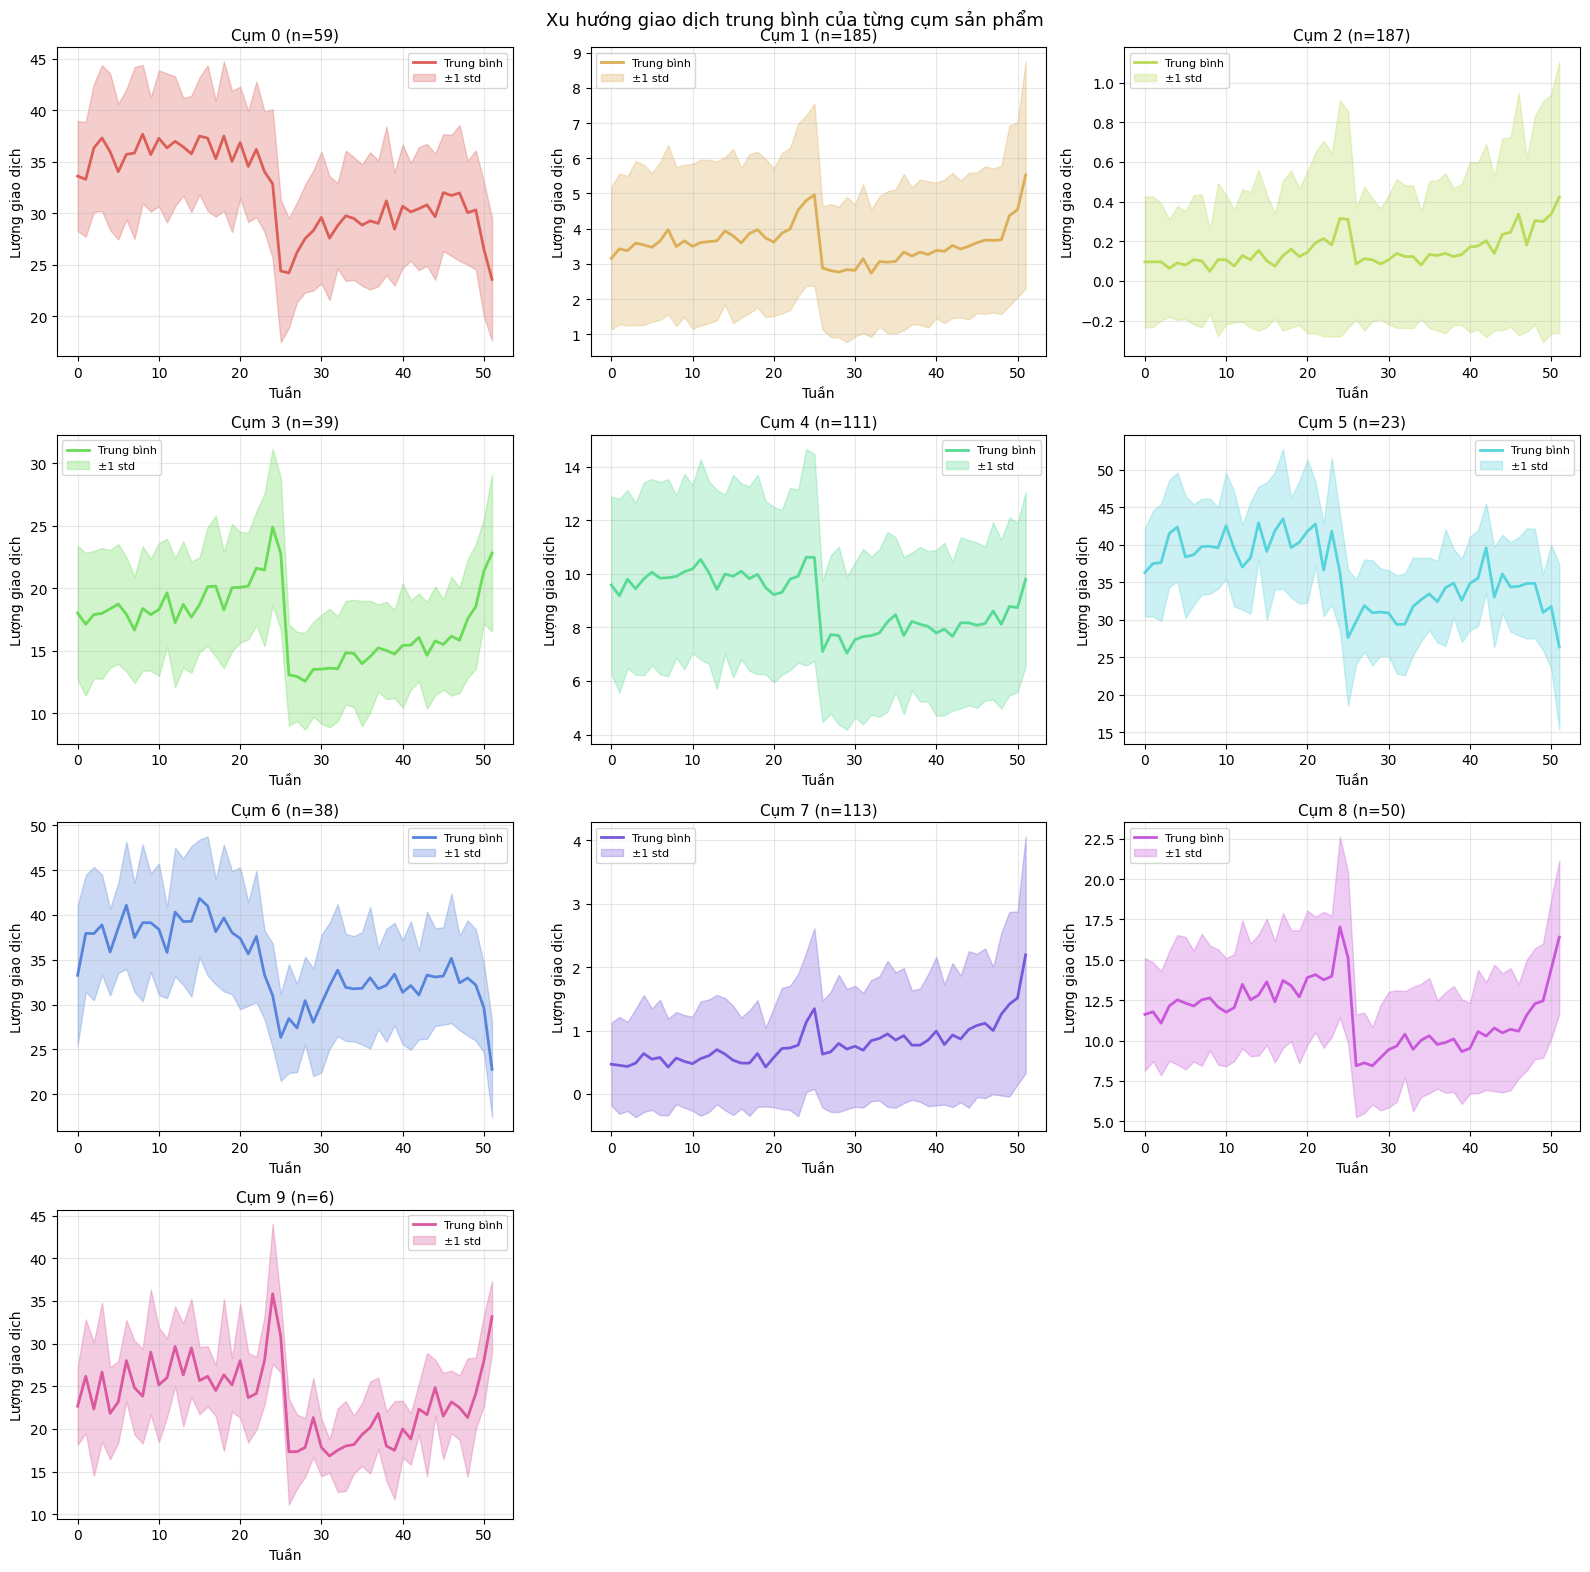

In [50]:
# ---- Phân tích đặc trưng mỗi cụm ----
week_labels = [f'W{i}' for i in range(X_sales.shape[1])]
fig, axes = plt.subplots(int(np.ceil(K_best / 3)), 3,
                          figsize=(16, int(np.ceil(K_best / 3)) * 4))
axes = axes.flatten()

for i in range(K_best):
    cluster_data = X_sales[labels_sales == i, :]
    mean_traj = cluster_data.mean(axis=0)
    std_traj = cluster_data.std(axis=0)
    x_axis = range(len(mean_traj))

    axes[i].plot(x_axis, mean_traj, color=palette[i], linewidth=2, label='Trung bình')
    axes[i].fill_between(x_axis, mean_traj - std_traj, mean_traj + std_traj,
                          alpha=0.3, color=palette[i], label='±1 std')
    axes[i].set_title(f'Cụm {i} (n={np.sum(labels_sales==i)})', fontsize=11)
    axes[i].set_xlabel('Tuần')
    axes[i].set_ylabel('Lượng giao dịch')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Ẩn các subplot thừa
for j in range(K_best, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Xu hướng giao dịch trung bình của từng cụm sản phẩm', fontsize=13)
plt.tight_layout()
plt.show()

In [51]:
# ---- Xuất kết quả phân cụm ----
result_df = df_sales[['Product_Code']].copy() if 'Product_Code' in df_sales.columns \
            else pd.DataFrame({'Product_Code': [f'P{i:04d}' for i in range(len(labels_sales))]})

result_df['Cluster'] = labels_sales
result_df['Cluster_Label'] = result_df['Cluster'].apply(lambda x: f'Nhóm_{x}')

print('Kết quả phân cụm (10 dòng đầu):')
print(result_df.head(10).to_string(index=False))

print(f'\nTổng: {len(result_df)} sản phẩm, phân thành {K_best} cụm.')
print('\nPhân bố:')
print(result_df['Cluster_Label'].value_counts().sort_index())

Kết quả phân cụm (10 dòng đầu):
Product_Code  Cluster Cluster_Label
          P1        4        Nhóm_4
          P2        1        Nhóm_1
          P3        4        Nhóm_4
          P4        4        Nhóm_4
          P5        4        Nhóm_4
          P6        1        Nhóm_1
          P7        1        Nhóm_1
          P8        4        Nhóm_4
          P9        8        Nhóm_8
         P10        3        Nhóm_3

Tổng: 811 sản phẩm, phân thành 10 cụm.

Phân bố:
Cluster_Label
Nhóm_0     59
Nhóm_1    185
Nhóm_2    187
Nhóm_3     39
Nhóm_4    111
Nhóm_5     23
Nhóm_6     38
Nhóm_7    113
Nhóm_8     50
Nhóm_9      6
Name: count, dtype: int64


---
## Tổng kết

| Phần | Nội dung | Phương pháp |
|------|----------|-------------|
| 2.1 – Ví dụ 1 | Dữ liệu nhân tạo 2D | GMM-EM tự cài từ Numpy |
| 2.1 – Bài tập 1 | Iris dataset (4D) | GMM-EM tự cài, đối sánh nhãn thực |
| 2.1 – Bài tập 2 | Dữ liệu nhân tạo 2D | So sánh K-Means vs. GMM-EM |
| 2.2 – Ví dụ 2 | Shopping data (thu nhập & mua sắm) | `sklearn.GaussianMixture` + BIC |
| 2.3 | Sales Transactions (52 tuần, 819 SP) | GMM + PCA + BIC (K=5..15) |